# OLIVES — Phase 0: Data Audit and Exploratory Analysis

**Project:** Clinically grounded, uncertainty-aware multimodal retinal biomarker detection
**Dataset:** OLIVES (Prabhushankar et al., NeurIPS 2022 Datasets & Benchmarks)

This notebook is the analysis front-end for the `olives_biomarkers` package. All logic lives in
`src/olives_biomarkers/` as importable classes; the notebook calls them and presents results.
Edit a `.py` file, re-run a cell, and the change is picked up (`autoreload` is on).

### What this notebook establishes

| # | Section | Question it answers |
|---|---------|--------------------|
| 1 | Environment & config | Where are we running, where is the data, what will be predicted? |
| 2 | Schema resolution | Do the declared columns exist verbatim in the parquet? |
| 3 | Manifest | Can we analyse 78k scans without touching 30 GB of image bytes? |
| 4 | Automated audit | What blocks or constrains modelling? |
| 5 | Cohort structure | How much *independent* evidence is there really? |
| 6 | Longitudinal structure | How do repeated visits constrain the split? |
| 7 | Duplicates | How much of the data is byte-identical repetition? |
| 8 | Label analysis | What is actually being predicted, and how imbalanced is it? |
| 9 | Label concentration | Which labels cannot support a patient-grouped test set? |
| 10 | Clinical variables | Do BCVA and CST carry biomarker signal at all? |
| 11 | Images | Are the scans clean, uniform, and correctly normalised? |
| 12 | Split design | What partitioning is defensible, and what does it cost? |
| 13 | Findings | What the experimental design must respect. |

> **Scope note.** The local copy is the Hugging Face parquet mirror. It has no fundus images,
> no 3D volumes, and no visit/week column — so the fundus and volume-level extensions in the
> project brief are blocked, and visit indices here are *inferred*. Section 2 makes this explicit.

---
## 1. Environment, configuration and imports

`RuntimeEnvironment` detects whether we are local or on Colab and resolves the data root
accordingly, so the same notebook runs in both places without edits.

In [1]:
%pip install -U ipython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 638.7/638.7 kB 9.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 70.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.2/86.2 kB 9.9 MB/s eta 0:00:00
  Attempting uninstall: traitlets
    Found existing installation: traitlets 5.7.1
    Uninstalling traitlets-5.7.1:
      Successfully uninstalled traitlets-5.7.1
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1

In [2]:
!git clone https://github.com/PasBless1/ClinBioGate.git
%cd ClinBioGate
%pip install -e .

Cloning into 'ClinBioGate'...
remote: Enumerating objects: 189, done.
remote: Counting objects: 100% (189/189), done.
remote: Compressing objects: 100% (143/143), done.
remote: Total 189 (delta 52), reused 175 (delta 39), pack-reused 0 (from 0)
Receiving objects: 100% (189/189), 4.31 MiB | 17.39 MiB/s, done.
Resolving deltas: 100% (52/52), done.
/content/ClinBioGate
Obtaining file:///content/ClinBioGate
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for olives-biomarkers (pyproject.toml) ... done
  Created wheel for olives-biomarkers: filename=olives_biomarkers-0.1.0-0.editable-py3-none-any.whl size=11991 sha256=8c3d2bab41a95db9aec857dad299e0f939c5076cccb86c80a7abd6767881420b
  Stored in directory: /tmp/pip-ephem-wheel-cache-n7blgc5s/wheels/92/24/54/cc1d24643a918ae37f4ced596feaa7d8e9a5077ff1123412a9
Successf

In [3]:
%load_ext autoreload
%autoreload 2

import sys, warnings
from pathlib import Path

# Resolve the repo root whether the notebook runs from notebooks/ or the repo root.
REPO_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()),
    Path.cwd(),
)
sys.path.insert(0, str(REPO_ROOT / "src"))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print("repo root:", REPO_ROOT)

repo root: /content/ClinBioGate


In [4]:
from olives_biomarkers.pipeline import OlivesPipeline
from olives_biomarkers.eda import OlivesEDA, EDAPlotter
from olives_biomarkers.data.dataset import ParquetImageReader

pipeline = OlivesPipeline.from_config(REPO_ROOT / "configs" / "data.yaml", repo_root=REPO_ROOT)
print(pipeline.describe())

OLIVES pipeline
          python: 3.13.15
        platform: Linux-6.6.122+-x86_64-with-glibc2.35
             cwd: /content/ClinBioGate
       repo_root: /content/ClinBioGate
          device: cuda
        is_colab: True
           torch: 2.11.0+cu128
  cuda_available: True
        gpu_name: NVIDIA A100-SXM4-40GB
   gpu_memory_gb: 42.4
    free_disk_gb: 70.2
      git_commit: 1ba535f
------------------------------------------------------------
          config: /content/ClinBioGate/configs/data.yaml
      experiment: unnamed
       data_root: /content/drive/MyDrive/olives/data/raw/OLIVES
     data_exists: False
       hf_config: disease_classification
      target_set: sixteen (16 labels)
        manifest: /content/ClinBioGate/data/manifests/disease_classification_train.parquet
 manifest_cached: False
------------------------------------------------------------
Target set    : sixteen (16 labels)
HF config     : disease_classification
Identifiers   : {'patient_id': 'Patient_ID', 'eye_i

### Colab

On Colab, mount Drive and point `data.root` at the uploaded copy. Section 11 shows how to export
a 2.3 GB image cache (just the modelling subset) rather than moving all 30 GB.

```python
pipeline.env.mount_drive()          # no-op when running locally
```

In [5]:
# Where figures are written.
FIGURES = REPO_ROOT / "outputs" / "figures" / "eda"
FIGURES.mkdir(parents=True, exist_ok=True)

plotter = EDAPlotter()
SAVE_FIGURES = True

def show(figure, name: str):
    """Display a figure and optionally persist it to outputs/figures/eda."""
    if figure is None:
        print(f"(no figure produced for {name})")
        return
    if SAVE_FIGURES:
        plotter.save(figure, FIGURES / f"{name}.png")
    plt.show()

---
## 2. Schema resolution

The parquet column names are awkward (`"Atrophy / thinning of retinal layers"`,
`"Fluid (IRF)"`, `"Scan (n/49)"`). `configs/label_schema.yaml` maps each one to a stable
snake_case key **once**, and `LabelSchema` validates that every declared column really exists
before anything else runs.

The schema file also records the fields the project brief assumes but this data source does
*not* provide, so they are reported as unresolved rather than quietly invented.

In [6]:
print(pipeline.schema.describe())

Target set    : sixteen (16 labels)
HF config     : disease_classification
Identifiers   : {'patient_id': 'Patient_ID', 'eye_id': 'Eye_ID', 'scan_number': 'Scan (n/49)'}
Clinical      : {'bcva': 'BCVA', 'cst': 'CST'}
Disease column: Disease Label
Labels:
   1. atrophy_thinning            <- 'Atrophy / thinning of retinal layers'
   2. ez_disruption               <- 'Disruption of EZ'
   3. dril                        <- 'DRIL'
   4. ir_hemorrhages              <- 'IR hemorrhages'
   5. irhrf                       <- 'IR HRF'
   6. pavf                        <- 'Partially attached vitreous face'
   7. favf                        <- 'Fully attached vitreous face'
   8. preretinal_tissue           <- 'Preretinal tissue/hemorrhage'
   9. vitreous_debris             <- 'Vitreous debris'
  10. vmt                         <- 'VMT'
  11. drt_me                      <- 'DRT/ME'
  12. irf                         <- 'Fluid (IRF)'
  13. srf                         <- 'Fluid (SRF)'
  14. rpe_disru

In [7]:
# Fields the brief expects that are absent here - stated explicitly, not assumed away.
pd.DataFrame(
    [
        {"field": name, "status": spec.get("status"), "note": " ".join(str(spec.get("note", "")).split())}
        for name, spec in pipeline.schema.unresolved_fields.items()
    ]
)

,field,status,note
0,visit_id_or_week,absent,"The HF mirror carries no visit/week column, an..."
1,fundus_image,absent,No near-IR fundus images in this mirror. Fundu...
2,oct_volume_npy,absent,No stitched 3D volumes. Volume-level modelling...
3,extended_clinical,absent,"DRSS, BMI, age, race, gender, HbA1c, leakage i..."


---
## 3. Building the manifest

Images are stored inline in the parquet, so the two configs occupy ~30 GB. Almost every question
below is about scalar columns, so `ManifestBuilder` makes **one** pass that keeps the metadata and
a hash of each image, and discards the bytes. The result is a few megabytes.

The hash is what makes duplicate detection possible at all — without it we could not tell a
repeated visit from a genuinely new one.

First run: ~90 s. Afterwards it loads from cache in under a second.

In [8]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [9]:
%pip install -q -U huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.8/795.8 kB 14.9 MB/s eta 0:00:00a 0:00:01


In [10]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="gOLIVES/OLIVES_Dataset",
    repo_type="dataset",
    local_dir="/content/drive/MyDrive/olives/data/raw/OLIVES",
    max_workers=4,
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 68 files:   0%|          | 0/68 [00:00<?, ?it/s]

'/content/drive/MyDrive/olives/data/raw/OLIVES'

In [11]:
manifest = pipeline.get_manifest(split="train")   # rebuild=True to force a rescan
print(manifest)
print()
for key, value in manifest.summary().items():
    print(f"{key:>26}: {value}")

09:03:09 | INFO    | olives.manifest | Building manifest: config=disease_classification split=train shards=32 hashes=True
09:03:22 | INFO    | olives.manifest |   shard  1/32 train-00000-of-00032.parquet     rows=2464
09:03:32 | INFO    | olives.manifest |   shard  2/32 train-00001-of-00032.parquet     rows=2464
09:03:41 | INFO    | olives.manifest |   shard  3/32 train-00002-of-00032.parquet     rows=2464
09:03:49 | INFO    | olives.manifest |   shard  4/32 train-00003-of-00032.parquet     rows=2464
09:03:55 | INFO    | olives.manifest |   shard  5/32 train-00004-of-00032.parquet     rows=2464
09:04:02 | INFO    | olives.manifest |   shard  6/32 train-00005-of-00032.parquet     rows=2464
09:04:08 | INFO    | olives.manifest |   shard  7/32 train-00006-of-00032.parquet     rows=2463
09:04:16 | INFO    | olives.manifest |   shard  8/32 train-00007-of-00032.parquet     rows=2463
09:04:25 | INFO    | olives.manifest |   shard  9/32 train-00008-of-00032.parquet     rows=2463
09:04:31 | INF

In [12]:
manifest.frame.head(3)

,row_uid,split_source,shard_name,shard_index,row_in_shard,patient_id,eye_id,scan_number,bcva,cst,disease_label,atrophy_thinning,ez_disruption,dril,ir_hemorrhages,irhrf,pavf,favf,preretinal_tissue,vitreous_debris,vmt,drt_me,irf,srf,rpe_disruption,ped_serous,shrm,image_path,image_hash,bcva_missing,cst_missing,disease_name,has_biomarkers,n_positive_labels,dup_group_id,dup_group_size,dup_rank,is_duplicate,visit_index,is_adjacent_duplicate,visit_uid,visit_size
0,0,train,train-00000-of-00032.parquet,0,0,58,58.0000,1.0000,97.0000,275.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.png,ecbb377741da8b09a04a8c40,False,False,DR,True,4,0,2,0,True,0,False,58_E58_V0,98
1,1,train,train-00000-of-00032.parquet,0,1,58,58.0000,1.0000,97.0000,275.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.png,ecbb377741da8b09a04a8c40,False,False,DR,True,4,0,2,1,True,0,True,58_E58_V0,98
2,2,train,train-00000-of-00032.parquet,0,2,58,58.0000,2.0000,97.0000,275.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.png,1b9805e57af8d79053785ae1,False,False,DR,True,3,1,2,0,True,0,False,58_E58_V0,98


In [13]:
# Column inventory: what the manifest carries and how complete each column is.
inventory = pd.DataFrame(
    {
        "dtype": manifest.frame.dtypes.astype(str),
        "n_missing": manifest.frame.isna().sum(),
        "pct_present": (100 * manifest.frame.notna().mean()).round(2),
        "n_unique": manifest.frame.nunique(),
    }
)
inventory

,dtype,n_missing,pct_present,n_unique
row_uid,int64,0,100.0000,78822
split_source,object,0,100.0000,1
shard_name,object,0,100.0000,32
shard_index,int64,0,100.0000,32
row_in_shard,int64,0,100.0000,2464
patient_id,int64,0,100.0000,87
eye_id,float64,637,99.1900,96
scan_number,float64,61329,22.1900,49
bcva,float64,637,99.1900,60
cst,float64,637,99.1900,303


**Read the `pct_present` column carefully.** `scan_number` is present on only ~22% of rows: it
belongs to the biomarker annotation block, not to every scan. It therefore cannot be used as a
general ordering key, and modelling rows must be filtered on `has_biomarkers` instead.

---
## 4. Automated audit

`DataAuditor` runs every Phase 0 check and grades findings as **blocker**, **warning** or **note**.
It writes `outputs/reports/data_audit.md` and `.json` so the same numbers can be cited later
without re-running anything.

In [14]:
report = pipeline.run_audit(manifest, write=True)

blockers = [f for f in report.findings if f.severity == "blocker"]
warnings_ = [f for f in report.findings if f.severity == "warning"]
notes = [f for f in report.findings if f.severity == "info"]

print(f"{len(blockers)} blockers | {len(warnings_)} warnings | {len(notes)} notes\n")
for finding in report.findings:
    print(f"  {finding}\n")

09:07:16 | INFO    | olives.audit | audit: check_source_files


09:07:20 | INFO    | olives.audit | audit: check_schema
09:07:20 | INFO    | olives.audit | audit: check_cohort
09:07:20 | INFO    | olives.audit | audit: check_visits
09:07:20 | INFO    | olives.audit | audit: check_scan_number_coverage
09:07:20 | INFO    | olives.audit | audit: check_disease_balance
09:07:20 | INFO    | olives.audit | audit: check_label_prevalence
09:07:20 | INFO    | olives.audit | audit: check_label_cooccurrence
09:07:20 | INFO    | olives.audit | audit: check_clinical_missingness
09:07:20 | INFO    | olives.audit | audit: check_duplicates
09:07:24 | INFO    | olives.audit | audit: check_unresolved_fields
09:07:24 | INFO    | olives.audit | audit: check_fundus_readiness
09:07:24 | INFO    | olives.audit | audit complete: 21 findings (0 blockers)
09:07:24 | INFO    | olives.pipeline | audit report written to /content/ClinBioGate/outputs/reports
0 blockers | 17 warnings | 4 notes

  [INFO] splits: This config ships a single `train` split; all partitioning is ours to 

In [15]:
# The audit's own section tables.
report.sections["label_prevalence"]

,label,display,n_labelled,n_positive,prevalence,n_patients_positive
0,irhrf,Intraretinal hyperreflective foci (IRHRF),17469,11751,0.6727,87
1,favf,Fully attached vitreous face (FAVF),17469,9612,0.5502,69
2,irf,Intraretinal fluid (IRF),17469,7393,0.4232,84
3,pavf,Partially attached vitreous face (PAVF),17469,5536,0.3169,59
4,drt_me,Diffuse retinal thickening / macular oedema (D...,17469,5363,0.3070,63
5,vitreous_debris,Vitreous debris (VD),17469,5358,0.3067,84
6,preretinal_tissue,Preretinal tissue / haemorrhage,17469,1468,0.0840,34
7,ez_disruption,Disruption of ellipsoid zone (EZ),17469,1026,0.0587,43
8,ir_hemorrhages,Intraretinal haemorrhages,17469,718,0.0411,49
9,srf,Subretinal fluid (SRF),17469,424,0.0243,25


---
## 5. Cohort structure — how much independent evidence exists

The headline count (78k scans) is misleading. Three views matter:

- **all rows** — everything in the parquet, duplicates included
- **unique images** — after removing byte-identical duplicates
- **biomarker-labelled** — deduplicated *and* carrying a complete 16-label vector; this is what a
  supervised model can actually train on

The gap between the first and last number is the single most important fact in this notebook.

In [16]:
eda = OlivesEDA(manifest, dedup_policy="keep_first")
eda.cohort_overview()

,view,n_scans,n_patients,n_eyes,n_visits
0,all rows,78822,87,97,1444
1,unique images (keep_first),70541,87,97,1440
2,biomarker-labelled,9396,87,96,192


The modelling set should come out near **9,400 labelled scans from 87 patients** — very close to
the 9,408 the OLIVES paper reports, which is a good independent check that the deduplication is
right.

Note the visit count in the labelled row: ~192 visits over 96 eyes, i.e. **exactly two per eye**.
That matches the paper's protocol — biomarkers were graded only on each eye's first and last visit.

In [17]:
patients = eda.per_patient_summary()
display(patients.head(10))
patients[["n_scans", "n_eyes", "n_visits", "n_labelled_scans", "bcva_mean", "cst_mean"]].describe().round(2)

,patient_id,n_scans,n_eyes,n_visits,disease,n_labelled_scans,bcva_first,bcva_last,bcva_mean,cst_first,cst_last,cst_mean,bcva_missing,bcva_change,cst_change
0,57,490,1,10,DR,98,88.0000,89.0000,90.1000,307.0000,298.0000,286.6000,0,1.0000,-9.0000
1,58,980,1,20,DR,98,97.0000,99.0000,96.3500,275.0000,269.0000,269.2500,0,2.0000,-6.0000
2,59,686,1,14,DR,98,68.0000,68.0000,68.2857,238.0000,222.0000,225.1429,0,0.0000,-16.0000
3,60,833,1,17,DR,98,86.0000,85.0000,84.8235,277.0000,267.0000,271.1176,0,-1.0000,-10.0000
4,61,980,1,20,DR,98,88.0000,89.0000,88.4000,303.0000,284.0000,299.3500,0,1.0000,-19.0000
5,62,980,1,20,DR,98,95.0000,97.0000,95.8000,256.0000,255.0000,261.2500,0,2.0000,-1.0000
6,63,980,1,20,DR,98,73.0000,94.0000,89.5500,223.0000,219.0000,220.4000,0,21.0000,-4.0000
7,64,784,1,16,DR,98,81.0000,84.0000,81.8125,267.0000,242.0000,251.3750,0,3.0000,-25.0000
8,65,980,1,20,DR,98,75.0000,82.0000,83.5500,236.0000,224.0000,226.4000,0,7.0000,-12.0000
9,66,784,1,16,DR,98,85.0000,83.0000,81.8125,311.0000,281.0000,286.1250,0,-2.0000,-30.0000


,n_scans,n_eyes,n_visits,n_labelled_scans,bcva_mean,cst_mean
count,87.0000,87.0000,87.0000,87.0000,87.0000,87.0000
mean,810.8200,1.1000,16.5500,108.0000,80.6000,302.8800
std,415.0400,0.3100,8.4700,29.8500,9.0600,62.9700
min,98.0000,1.0000,2.0000,92.0000,40.0000,163.5000
25%,539.0000,1.0000,11.0000,98.0000,75.5000,259.0800
50%,833.0000,1.0000,17.0000,98.0000,81.4600,283.7900
75%,"1,029.0000",1.0000,21.0000,98.0000,87.6600,349.5900
max,"2,009.0000",2.0000,41.0000,196.0000,96.3500,459.0000


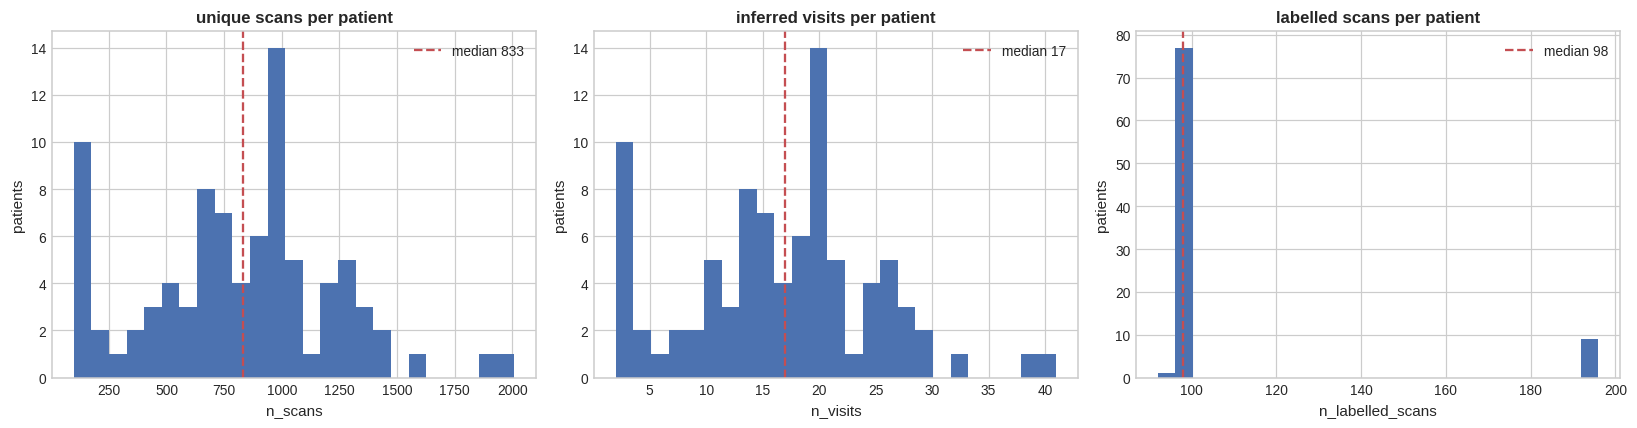

In [18]:
show(plotter.per_patient_distribution(patients), "05_per_patient_distribution")

In [19]:
eda.disease_distribution()

,disease,n_scans,n_eyes,n_patients,pct_patients
0,DME,37616,56,47,54.0000
1,DR,32925,41,40,46.0000


DR and DME are close to balanced at patient level, which is convenient: the split can stratify on
disease without distorting the partitions. (In the source trials, DR comes from PRIME and DME from
TREX-DME, so "disease" is partly a proxy for "trial".)

---
## 6. Longitudinal structure

This mirror has **no visit or week column**. `VisitInferencer` reconstructs visits from the fact
that BCVA and CST are measured once per visit and stay constant across that visit's 49 B-scans:
a new visit opens when `(bcva, cst)` changes, or when 49 scans have accumulated.

These indices are **inferred**, not authoritative. They are good enough to characterise the
repeated-measures structure — which is what governs the split — but no visit-level *result*
should be reported without manual verification.

96 eyes, 1429 inferred visits
count   96.0000
mean    14.9000
std      7.4000
min      2.0000
25%     10.0000
50%     16.0000
75%     20.0000
max     28.0000
Name: n_visits, dtype: float64


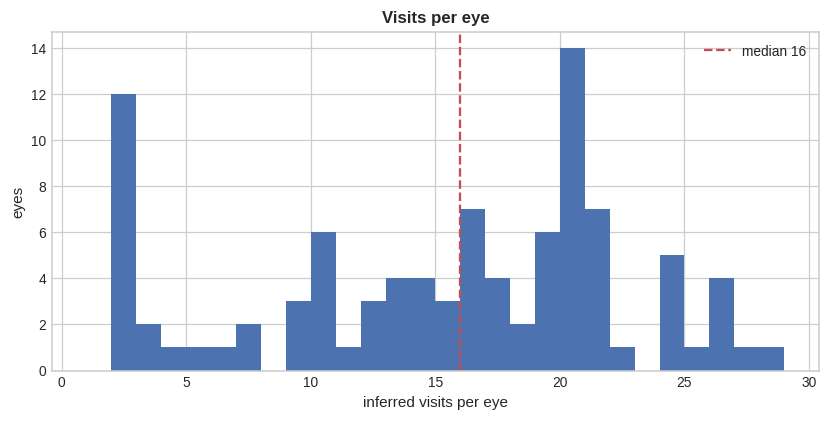

In [20]:
visits = eda.visits_per_eye()
print(f"{len(visits)} eyes, {visits['n_visits'].sum()} inferred visits")
print(visits["n_visits"].describe().round(1))

figure, axis = plt.subplots(figsize=(9, 4))
axis.hist(visits["n_visits"], bins=range(1, int(visits["n_visits"].max()) + 2), color="#4C72B0")
axis.axvline(visits["n_visits"].median(), color="#C44E52", ls="--",
             label=f"median {visits['n_visits'].median():.0f}")
axis.set_xlabel("inferred visits per eye"); axis.set_ylabel("eyes")
axis.set_title("Visits per eye"); axis.legend()
show(figure, "06_visits_per_eye")

In [21]:
trajectories = eda.visit_trajectories()
trajectories.head(10)

,patient_id,eye_id,visit_index,n_scans,bcva,cst,disease,has_biomarkers,bcva_change_from_first,cst_change_from_first,bcva_change_from_previous
0,57,57.0000,0,49,88.0000,307.0000,DR,True,0.0000,0.0000,NaN
1,57,57.0000,1,49,94.0000,286.0000,DR,False,6.0000,-21.0000,6.0000
2,57,57.0000,2,49,95.0000,288.0000,DR,False,7.0000,-19.0000,1.0000
3,57,57.0000,3,49,94.0000,285.0000,DR,False,6.0000,-22.0000,-1.0000
4,57,57.0000,4,49,87.0000,283.0000,DR,False,-1.0000,-24.0000,-7.0000
5,57,57.0000,5,49,88.0000,283.0000,DR,False,0.0000,-24.0000,1.0000
6,57,57.0000,6,49,89.0000,273.0000,DR,False,1.0000,-34.0000,1.0000
7,57,57.0000,7,49,93.0000,271.0000,DR,True,5.0000,-36.0000,4.0000
8,57,57.0000,8,49,84.0000,292.0000,DR,False,-4.0000,-15.0000,-9.0000
9,57,57.0000,9,49,89.0000,298.0000,DR,False,1.0000,-9.0000,5.0000


,visit_index,n_eyes,mean_bcva,mean_cst,mean_bcva_change_from_first,std_bcva_change_from_first,mean_visit_to_visit_change,pct_improved_vs_previous
0,0,96,74.3400,386.1000,0.0000,0.0000,NaN,0.0000
1,1,97,80.7200,295.3000,6.3800,9.0700,6.3750,70.1000
2,2,85,80.7400,288.3000,5.7900,8.7900,0.2020,51.8000
3,3,82,81.8100,283.7000,6.9100,8.3400,1.2220,46.3000
4,4,82,81.6200,283.6000,6.7200,8.0900,-0.4320,40.2000
5,5,81,80.7600,290.5000,6.0200,7.9100,-0.7380,35.8000
6,6,80,81.4100,284.5000,6.7000,8.6800,0.5440,50.0000
7,7,78,81.4700,286.4000,6.8100,9.1400,-0.0130,41.0000
8,8,78,80.8200,287.9000,6.1600,9.5500,-0.6490,33.3000
9,9,75,81.5400,284.9000,6.8200,9.5900,0.7030,50.7000


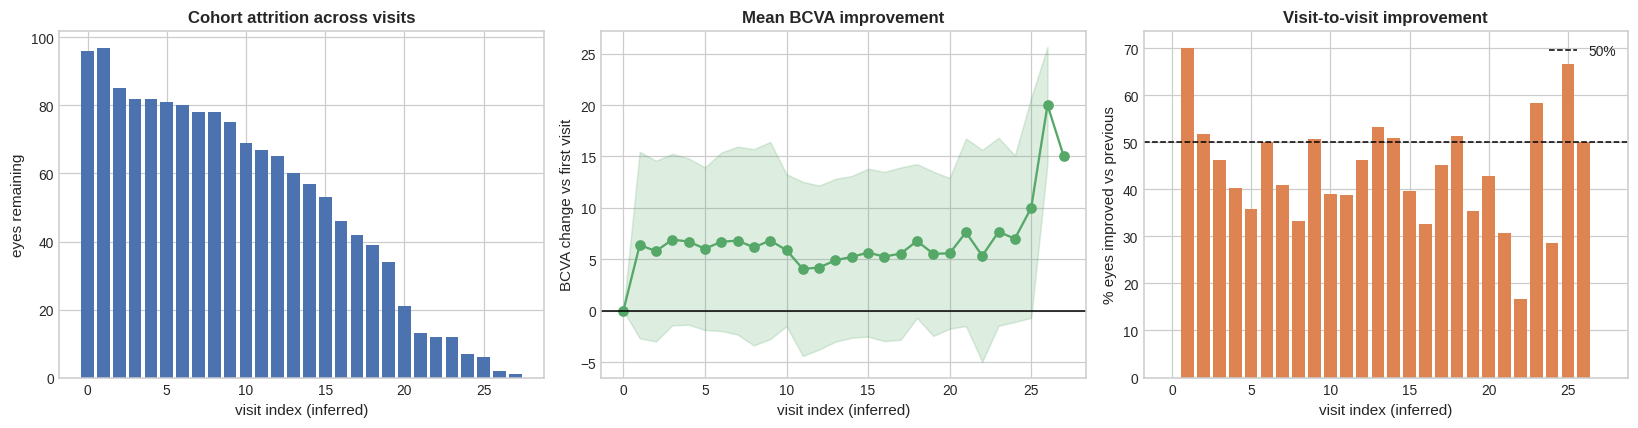

In [22]:
progression = eda.treatment_progression()
display(progression.head(15))
show(plotter.treatment_progression(progression), "06_treatment_progression")

This reproduces the shape of Figure 5 in the OLIVES paper: BCVA improves substantially against
baseline, while the *visit-to-visit* improvement rate decays. The attrition panel explains why —
the cohort thins with each visit, and the patients who keep returning are the harder ones, which
drags the later averages down. It is survivorship, not deterioration.

,patient_id,eye_id,n_visits,bcva_std,bcva_range,cst_std,cst_range
count,96.0000,96.0000,96.0000,96.0000,96.0000,96.0000,96.0000
mean,164.9600,48.5000,14.8900,4.7100,14.4900,48.3800,131.8000
std,76.5200,27.8600,7.3700,3.0500,7.4500,57.0100,122.9300
min,57.0000,1.0000,2.0000,0.0000,0.0000,2.3400,7.0000
25%,80.7500,24.7500,10.0000,2.7700,9.0000,7.1500,25.0000
50%,208.5000,48.5000,16.0000,3.7200,13.0000,26.6600,101.0000
75%,232.0000,72.2500,20.0000,5.5700,19.0000,69.2700,206.7500
max,256.0000,96.0000,28.0000,16.2600,48.0000,277.1900,498.0000


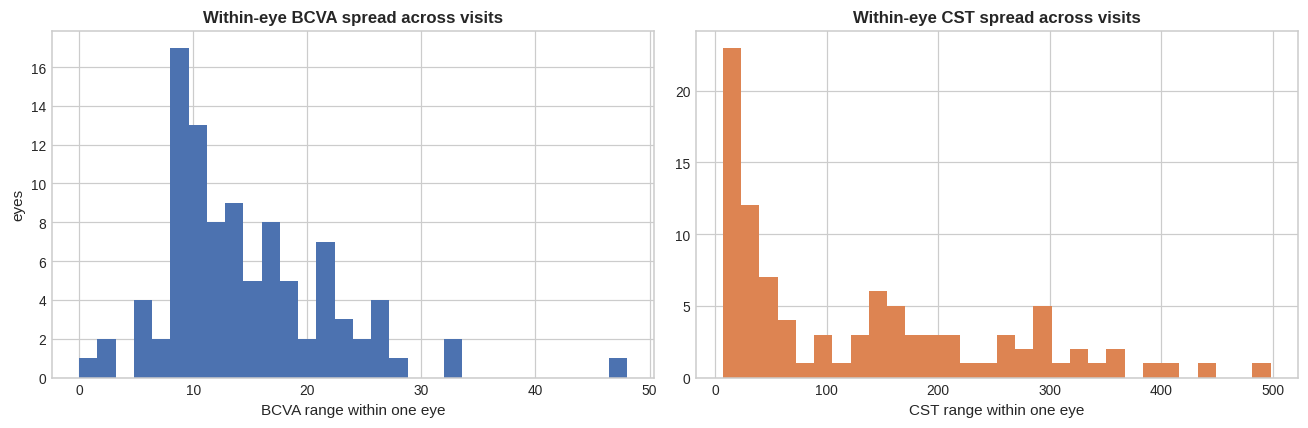

In [23]:
variability = eda.within_eye_variability()
display(variability.describe().round(2))

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(variability["bcva_range"].dropna(), bins=30, color="#4C72B0")
axes[0].set_xlabel("BCVA range within one eye"); axes[0].set_ylabel("eyes")
axes[0].set_title("Within-eye BCVA spread across visits")
axes[1].hist(variability["cst_range"].dropna(), bins=30, color="#DD8452")
axes[1].set_xlabel("CST range within one eye")
axes[1].set_title("Within-eye CST spread across visits")
figure.tight_layout()
show(figure, "06_within_eye_variability")

In [24]:
# Biomarkers are graded only at the first and last visit - so this is the treatment contrast.
eda.first_last_visit_comparison()

,label,first_prevalence,first_n,last_prevalence,last_n,change
0,atrophy_thinning,0.0068,4704,0.0286,4692,0.0218
1,ez_disruption,0.0264,4704,0.1023,4692,0.0759
2,dril,0.0036,4704,0.0032,4692,-0.0004
3,ir_hemorrhages,0.0644,4704,0.0149,4692,-0.0495
4,irhrf,0.7710,4704,0.5778,4692,-0.1932
5,pavf,0.3231,4704,0.3120,4692,-0.0111
6,favf,0.5755,4704,0.5347,4692,-0.0408
7,preretinal_tissue,0.0823,4704,0.0895,4692,0.0072
8,vitreous_debris,0.3376,4704,0.2660,4692,-0.0716
9,vmt,0.0006,4704,0.0015,4692,0.0009


The first-versus-last contrast is the treatment effect the paper describes as a *domain shift*:
models trained on first-visit scans transfer poorly to last-visit scans. Two consequences for us:
a split must not place one eye's first visit in train and its last visit in test, and any
"before/after treatment" comparison is a separate experiment, not a free result.

---
## 7. Duplicate images

The dataset card warns that some visits repeat an earlier visit's scans (it names patient 61,
W8 vs W12). Hashing every image quantifies it.

Two distinct phenomena, which need different treatment:

- **adjacent duplicates** — the same row emitted twice in succession; a storage artefact
- **repeated-visit duplicates** — a later visit whose images are byte-identical to an earlier one;
  a genuine clinical time point that happens to carry the same pixels

In [25]:
duplicates = eda.duplicate_analysis()
pd.Series(duplicates).to_frame("value")

,value
available,True
n_rows,78822
n_unique_images,70541
n_duplicate_rows,16562
pct_duplicate_rows,21.0100
n_duplicate_groups,8281
max_group_size,2
n_adjacent_duplicate_rows,8085
n_non_adjacent_duplicate_rows,8477
groups_spanning_multiple_patients,0


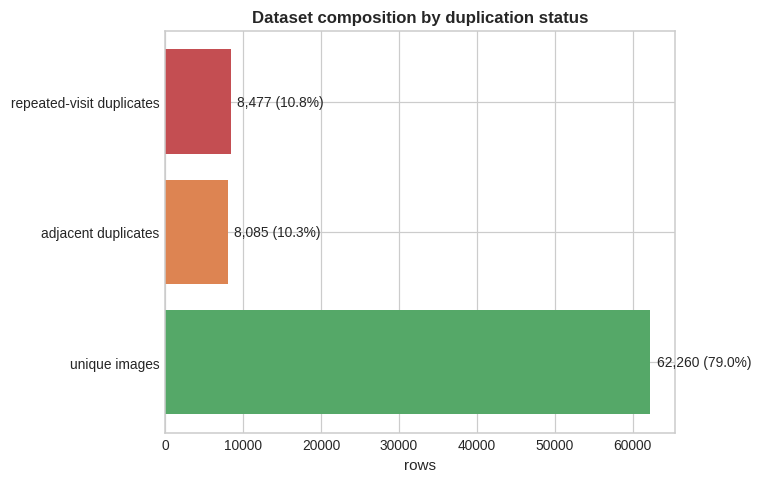

In [26]:
show(plotter.duplicate_summary(duplicates), "07_duplicate_composition")

In [27]:
# Which eyes have visits that repeat an earlier visit's images.
eda.duplicate_visits()

,patient_id,eye_id,n_repeated_images,visits_involved
1,79,79.0000,98,"[79_E79_V0, 79_E79_V13]"
0,61,61.0000,49,"[61_E61_V18, 61_E61_V3]"
2,203,2.0000,49,"[203_E2_V2, 203_E2_V3]"


About **21% of rows are byte-identical to another row**. Crucially, no duplicate group spans two
different patients, so patient-grouped splitting already contains them — but they still have to be
removed before counting, or every prevalence figure is inflated by repetition.

`dedup_policy: keep_first` in `configs/data.yaml` controls this; the modelling frame applies it.

---
## 8. Label analysis — what is actually being predicted

In [28]:
prevalence = eda.label_prevalence()
prevalence[["label", "display", "n_labelled", "n_positive", "pct", "n_patients_positive", "rarity"]]

,label,display,n_labelled,n_positive,pct,n_patients_positive,rarity
0,irhrf,Intraretinal hyperreflective foci (IRHRF),9396,6338,67.4500,87,common (>20%)
1,favf,Fully attached vitreous face (FAVF),9396,5216,55.5100,69,common (>20%)
2,irf,Intraretinal fluid (IRF),9396,4087,43.5000,84,common (>20%)
3,drt_me,Diffuse retinal thickening / macular oedema (D...,9396,3003,31.9600,63,common (>20%)
4,pavf,Partially attached vitreous face (PAVF),9396,2984,31.7600,59,common (>20%)
5,vitreous_debris,Vitreous debris (VD),9396,2836,30.1800,84,common (>20%)
6,preretinal_tissue,Preretinal tissue / haemorrhage,9396,807,8.5900,34,uncommon (5-20%)
7,ez_disruption,Disruption of ellipsoid zone (EZ),9396,604,6.4300,43,uncommon (5-20%)
8,ir_hemorrhages,Intraretinal haemorrhages,9396,373,3.9700,49,rare (1-5%)
9,srf,Subretinal fluid (SRF),9396,233,2.4800,25,rare (1-5%)


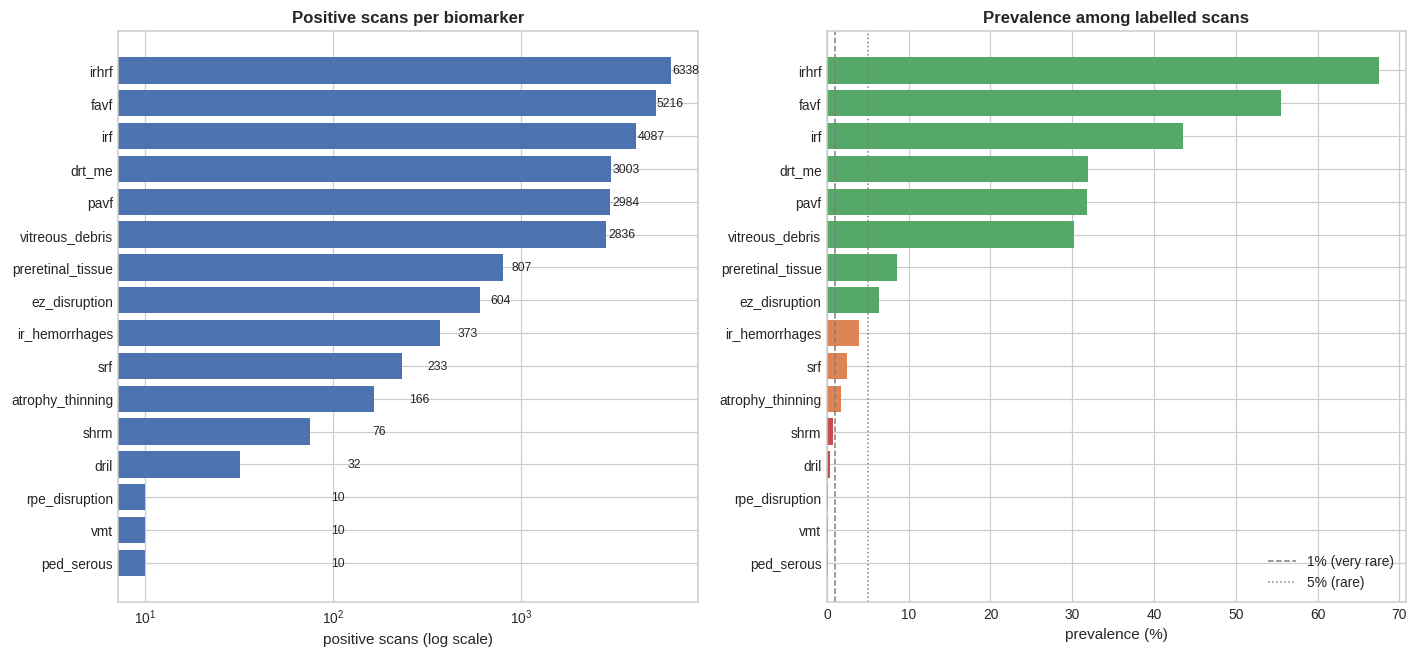

In [29]:
show(plotter.label_prevalence(prevalence), "08_label_prevalence")

The imbalance spans **three orders of magnitude**: IRHRF appears on roughly two thirds of scans,
while PED (serous), VMT and RPE disruption appear on well under 1%. A single global 0.5 threshold
cannot serve both ends of that range, which is why the pipeline fits one threshold per label on
validation data.

In [30]:
cardinality = eda.label_cardinality()
pd.Series(cardinality).to_frame("value")

,value
mean_labels_per_scan,2.8510
median_labels_per_scan,3.0000
std_labels_per_scan,1.4330
min_labels_per_scan,0.0000
max_labels_per_scan,8.0000
scans_with_no_label,211.0000
pct_scans_with_no_label,2.2500
n_unique_label_vectors,292.0000
n_possible_label_vectors,"65,536.0000"
label_density,0.1782


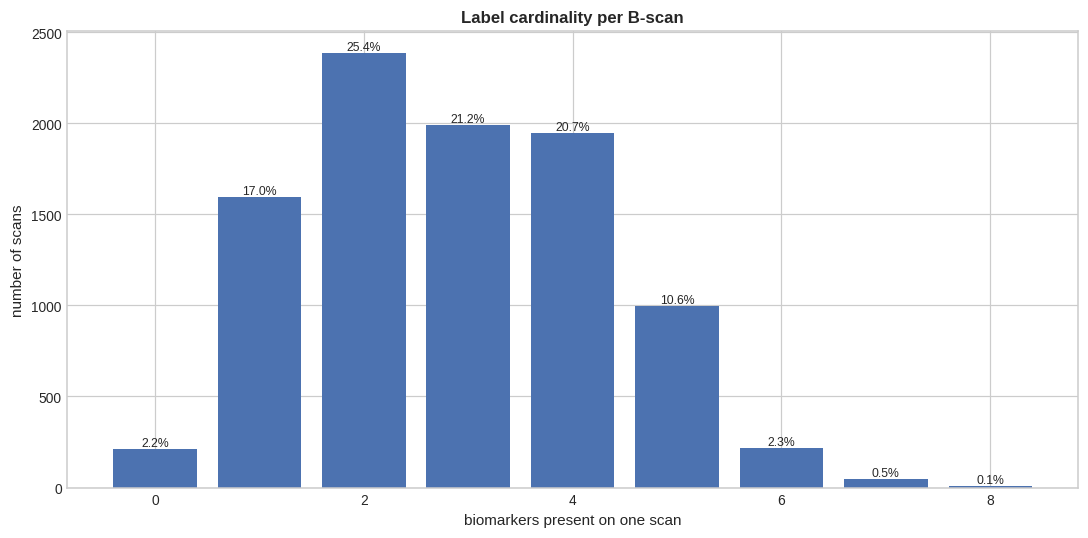

In [31]:
show(plotter.label_cardinality(eda.label_cardinality_distribution()), "08_label_cardinality")

Scans carry roughly **3 biomarkers on average**, and only 292 of the 65,536 possible label vectors
ever occur. The task is genuinely multilabel with strong structure between labels — not 16
independent binary problems — which is what makes exact-match a harsh but informative metric.

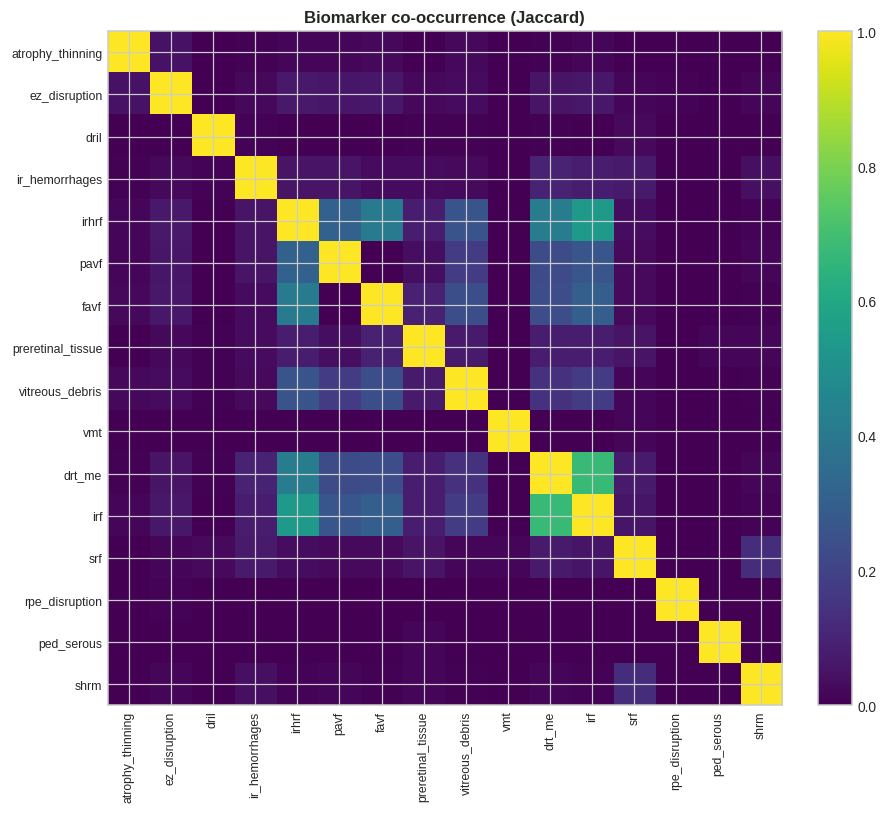

In [32]:
show(plotter.cooccurrence_heatmap(eda.label_cooccurrence_matrix("jaccard")), "08_cooccurrence_jaccard")

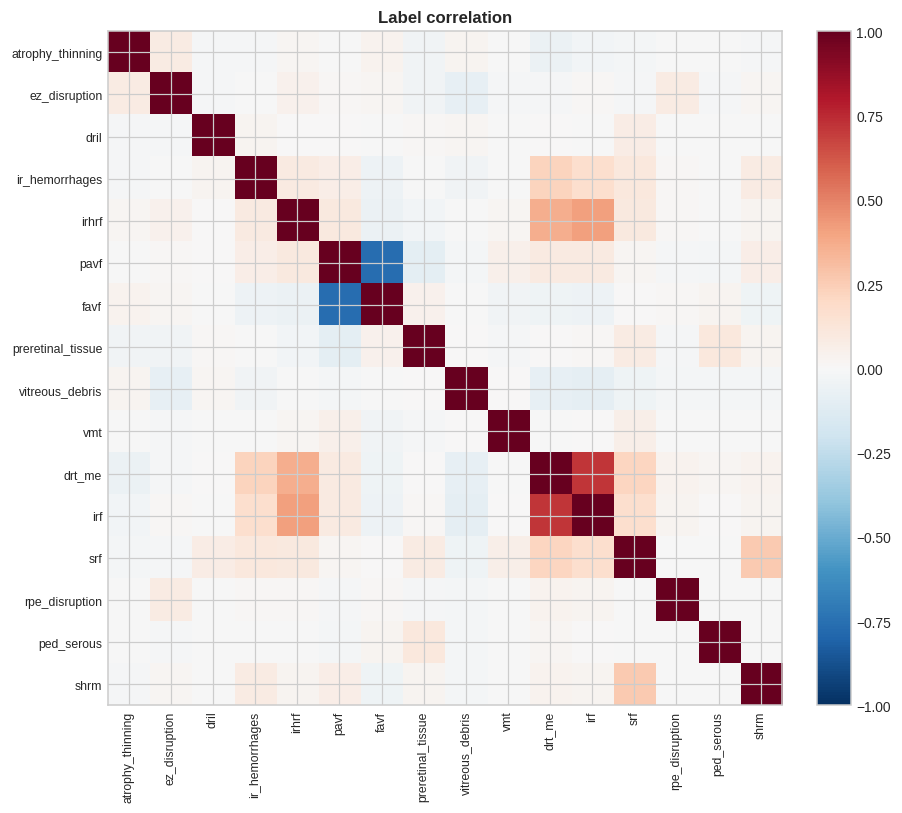

In [33]:
show(plotter.correlation_heatmap(eda.label_correlation()), "08_label_correlation")

Look for the **PAVF / FAVF** pair: partially- and fully-attached vitreous face are near-mutually
exclusive by definition, so they should show strong negative correlation. If a trained model
predicts both as present on the same scan, that is a concrete, checkable failure.

In [34]:
eda.top_label_combinations(top_n=15)

,combination,n_scans,pct
0,favf,828,8.8100
1,"irhrf, favf, drt_me, irf",772,8.2200
2,"irhrf, favf",669,7.1200
3,"irhrf, pavf, drt_me, irf",524,5.5800
4,"irhrf, favf, vitreous_debris",496,5.2800
5,"irhrf, pavf",449,4.7800
6,"favf, vitreous_debris",428,4.5600
7,pavf,416,4.4300
8,"irhrf, favf, irf",276,2.9400
9,"irhrf, pavf, vitreous_debris, drt_me, irf",231,2.4600


,label,DME_prevalence,DME_n_positive,DR_prevalence,DR_n_positive,difference
0,atrophy_thinning,0.0298,163,0.0008,3,0.0290
1,ez_disruption,0.0926,507,0.0247,97,0.0679
2,dril,0.0016,9,0.0059,23,-0.0043
3,ir_hemorrhages,0.0418,229,0.0367,144,0.0051
4,irhrf,0.7224,3956,0.6077,2382,0.1147
5,pavf,0.3280,1796,0.3031,1188,0.0249
6,favf,0.6119,3351,0.4758,1865,0.1361
7,preretinal_tissue,0.1174,643,0.0418,164,0.0756
8,vitreous_debris,0.2409,1319,0.3870,1517,-0.1461
9,vmt,0.0011,6,0.0010,4,0.0001


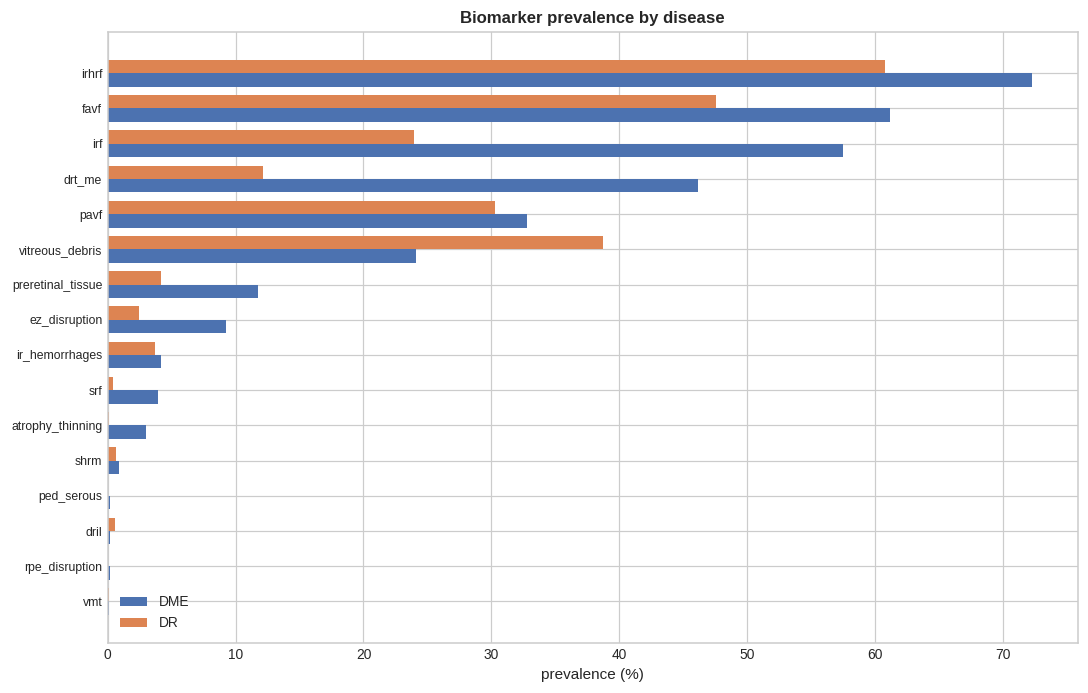

In [35]:
by_disease = eda.label_prevalence_by_disease()
display(by_disease)
show(plotter.prevalence_by_disease(by_disease), "08_prevalence_by_disease")

Biomarkers overlap heavily across DR and DME — exactly the paper's point that *"biomarkers in
isolation are insufficient to diagnose disease states"*. Useful as a sanity check, and a reason not
to feed the disease label to a biomarker model: it would leak trial identity.

---
## 9. Label concentration and split feasibility

A label with 10 positives is not merely hard to learn — if those positives sit inside one or two
patients, a patient-grouped test set will frequently contain **zero** of them, and the per-label
metric is then undefined rather than bad.

In [36]:
concentration = eda.label_patient_concentration()
concentration

,label,n_positive,n_patients_with_positive,pct_patients,largest_patient_share,at_risk_of_empty_fold
13,rpe_disruption,10,5,5.7000,0.4000,False
14,ped_serous,10,1,1.1000,1.0000,True
9,vmt,10,3,3.4000,0.4000,True
2,dril,32,4,4.6000,0.5940,True
15,shrm,76,14,16.1000,0.2630,False
0,atrophy_thinning,166,14,16.1000,0.4640,False
12,srf,233,25,28.7000,0.1930,False
3,ir_hemorrhages,373,49,56.3000,0.1420,False
1,ez_disruption,604,43,49.4000,0.1030,False
7,preretinal_tissue,807,34,39.1000,0.1210,False


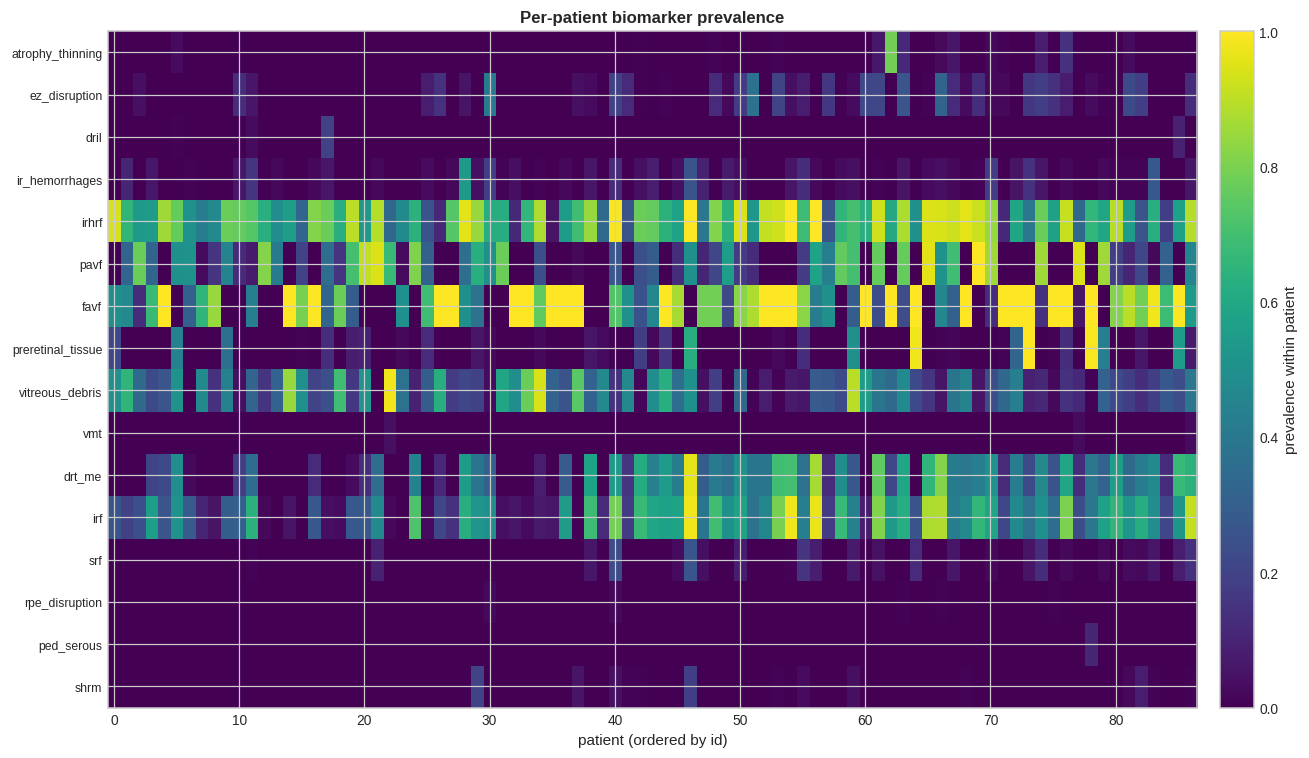

In [37]:
show(plotter.patient_label_heatmap(eda.label_prevalence_by_patient()), "09_patient_label_heatmap")

The heatmap shows how patient-specific the rare labels are: solid columns mean a biomarker is a
property of a *patient*, not of an individual scan. For those labels the model can succeed simply
by recognising the patient, which patient-grouped splitting correctly makes impossible.

,label,n_positive_total,n_patients_with_positive,expected_test_patients_with_positive,expected_test_positives,probability_zero_in_test,usable_in_test
13,rpe_disruption,10,5,0.8000,1.5000,0.4630,False
14,ped_serous,10,1,0.1000,1.5000,0.8600,False
9,vmt,10,3,0.4000,1.5000,0.6340,False
2,dril,32,4,0.6000,4.8000,0.5420,False
15,shrm,76,14,2.1000,11.4000,0.1020,True
0,atrophy_thinning,166,14,2.1000,24.9000,0.1020,True
12,srf,233,25,3.8000,34.9000,0.0120,True
3,ir_hemorrhages,373,49,7.3000,55.9000,0.0000,True
1,ez_disruption,604,43,6.5000,90.6000,0.0000,True
7,preretinal_tissue,807,34,5.1000,121.0000,0.0020,True


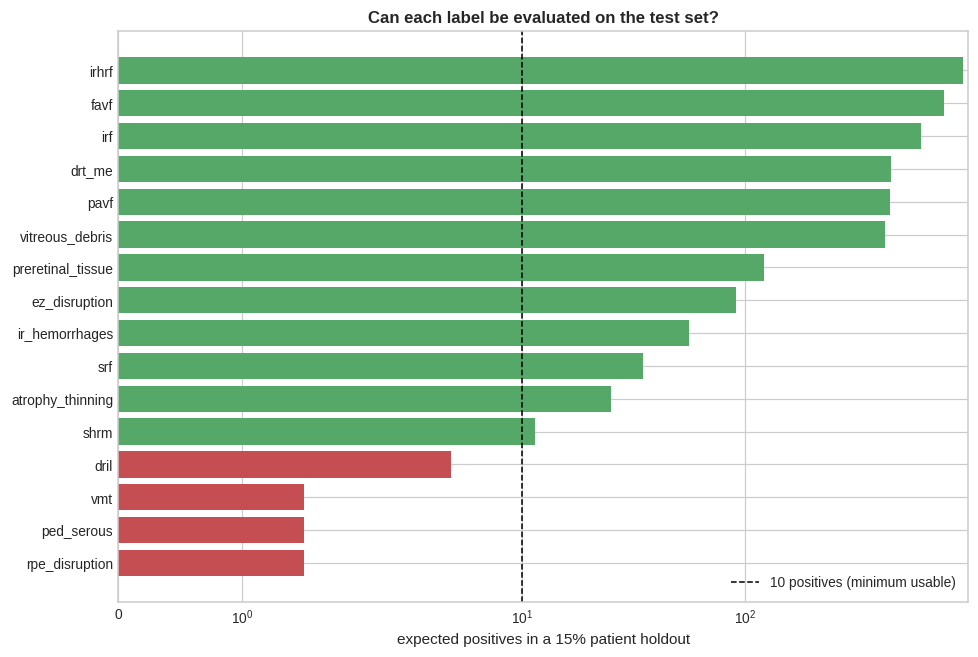

In [38]:
feasibility = eda.split_feasibility(test_fraction=0.15)
display(feasibility)
show(plotter.split_feasibility(feasibility), "09_split_feasibility")

**This table drives the target-set decision.** Labels marked `usable_in_test = False` cannot be
evaluated at a 15% patient holdout. The 6-label MVP (`target_set: six` — IRHRF, PAVF, FAVF, IRF,
DRT/ME, vitreous debris) is precisely the subset that survives, which is why the VIP Cup chose it.

Reporting the 16-label model is still worthwhile, but per-label results for the rare labels must be
reported as undefined rather than as a number.

---
## 10. Clinical variables — do BCVA and CST carry biomarker signal?

This is the crux of the research question. If BCVA and CST separate biomarkers, clinical fusion has
something to work with; if they do not, the honest result is a negative one.

In [39]:
eda.clinical_summary()

,feature,n,n_missing,pct_missing,mean,std,min,q25,median,q75,max,n_unique,skew
0,bcva,70002,539,0.7600,80.1500,10.7100,27.0000,74.0000,83.0000,87.0000,100.0000,60,-1.2830
1,cst,70002,539,0.7600,299.8700,79.9400,151.0000,253.0000,272.0000,328.0000,723.0000,303,1.7400


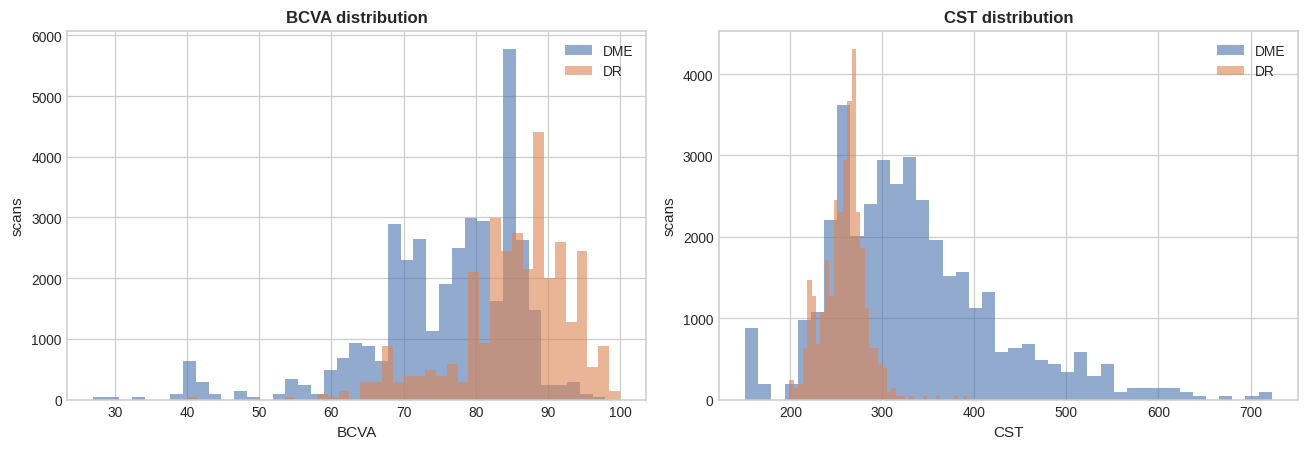

In [40]:
show(plotter.clinical_distributions(eda.unique, by_disease=True), "10_clinical_distributions")

In [41]:
eda.clinical_by_disease()

bcva                                             cst                                            
              count    mean     std  median     min      max  count     mean     std   median      min      max
disease_name                                                                                                   
DME           37616 75.8000 10.8500 78.0000 27.0000  98.0000  37616 335.2000 93.4500 321.0000 151.0000 723.0000
DR            32386 85.1900  7.9900 87.0000 40.0000 100.0000  32386 258.8400 23.1700 261.0000 199.0000 392.0000

In [42]:
# Missingness: concentrated, not scattered.
eda.missingness_profile()

,patient_id,bcva_missing_sum,bcva_missing_mean,cst_missing_sum,cst_missing_mean
0,79,637,0.4483,637,0.4483


Missing BCVA/CST is confined to **one patient (79)**, as the dataset card warns. Because it is
concentrated rather than random, the missingness indicator is itself informative — dropping those
rows would silently remove one patient from the cohort, so the pipeline imputes on the training
fold and keeps an explicit indicator.

In [43]:
association = eda.clinical_label_association()
association[["label", "n_present", "n_absent", "cst_present", "cst_absent",
             "cst_delta", "cst_cohens_d", "bcva_delta", "bcva_cohens_d"]]

,label,n_present,n_absent,cst_present,cst_absent,cst_delta,cst_cohens_d,bcva_delta,bcva_cohens_d
0,srf,233,9163,524.4800,330.1900,194.2900,1.6470,-11.7900,-1.0790
1,drt_me,3003,6393,426.5400,292.0100,134.5400,1.1410,-9.9800,-0.9130
2,rpe_disruption,10,9386,459.9000,334.8700,125.0300,1.0600,-11.8200,-1.0810
3,ped_serous,10,9386,459.0000,334.8700,124.1300,1.0530,-2.2100,-0.2020
4,irf,4087,5309,394.7900,288.9800,105.8100,0.8970,-8.7200,-0.7980
5,ir_hemorrhages,373,9023,427.6600,331.1700,96.4900,0.8180,-4.8200,-0.4410
6,irhrf,6338,3058,353.4500,296.7700,56.6700,0.4810,-4.7100,-0.4310
7,shrm,76,9320,390.3700,334.5500,55.8200,0.4730,-5.1900,-0.4750
8,preretinal_tissue,807,8589,384.7000,330.3300,54.3600,0.4610,-1.1700,-0.1070
9,atrophy_thinning,166,9230,303.2600,335.5700,-32.3200,-0.2740,1.1400,0.1040


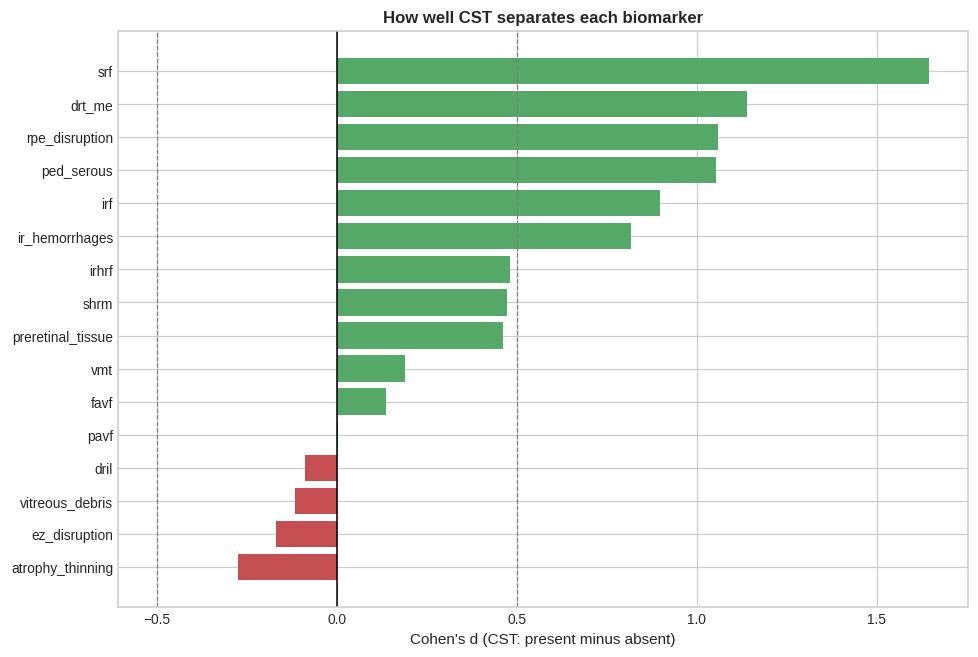

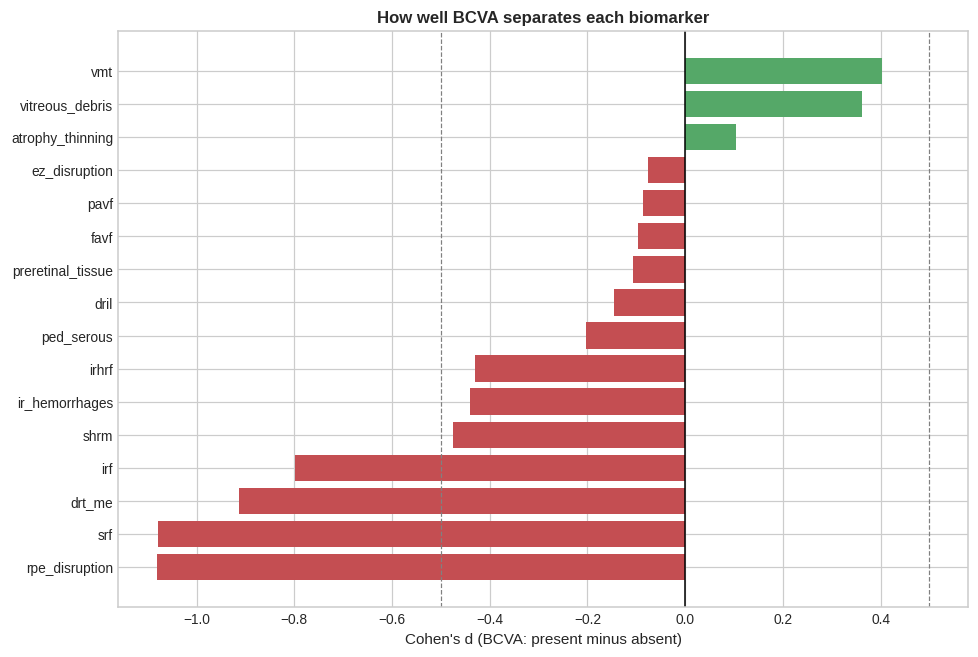

In [44]:
show(plotter.clinical_label_association(association, "cst"), "10_cst_association")
show(plotter.clinical_label_association(association, "bcva"), "10_bcva_association")

In [45]:
eda.clinical_correlation()

,atrophy_thinning,ez_disruption,dril,ir_hemorrhages,irhrf,pavf,favf,preretinal_tissue,vitreous_debris,vmt,drt_me,irf,srf,rpe_disruption,ped_serous,shrm
bcva,-0.0010,-0.0210,-0.0090,-0.0690,-0.2080,-0.0510,-0.0400,-0.0430,0.1720,0.0140,-0.4430,-0.4180,-0.1650,-0.0350,-0.0140,-0.0510
cst,-0.0170,-0.0360,-0.0160,0.1380,0.2090,0.0120,0.0350,0.1720,-0.0600,0.0050,0.5210,0.4410,0.2010,0.0240,0.0370,0.0320


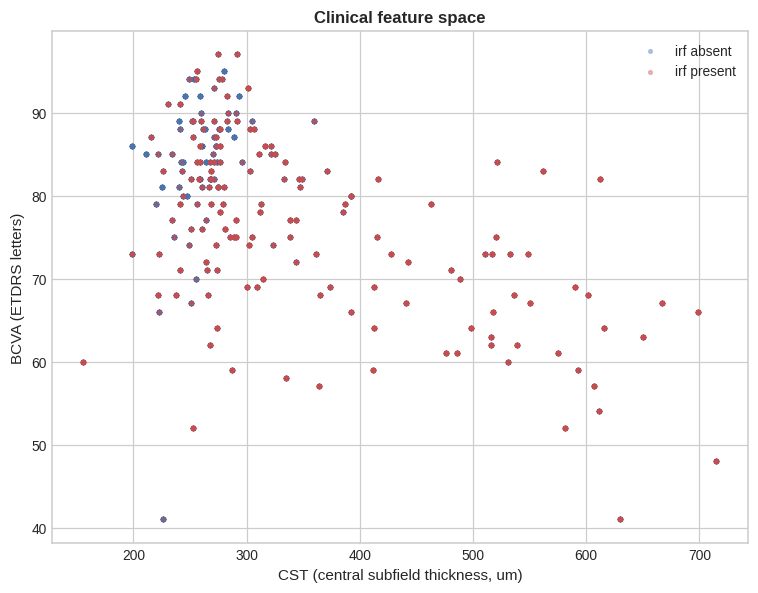

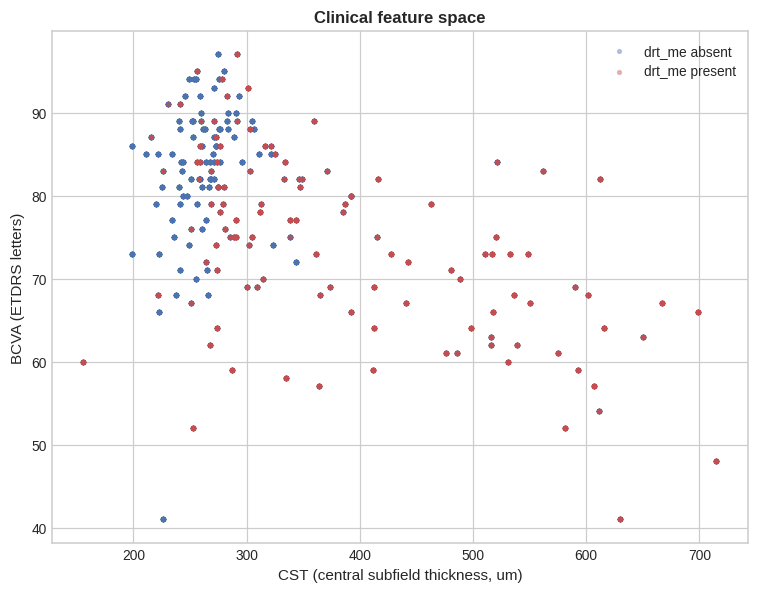

In [46]:
show(plotter.clinical_scatter(eda.labelled, label="irf"), "10_clinical_scatter_irf")
show(plotter.clinical_scatter(eda.labelled, label="drt_me"), "10_clinical_scatter_drtme")

**Interpretation.** CST is macular thickness, so it should separate the fluid and thickening
biomarkers (IRF, DRT/ME) and be largely uninformative about vitreous-face biomarkers (PAVF, FAVF)
— those concern structure above the retina that CST does not measure. Check that pattern above:
if it holds, it is mechanistic support for gating rather than an accident of correlation.

Note the ceiling on what fusion can achieve: CST is one number per *volume*, so it is identical
across all 49 B-scans of a visit while the biomarkers vary slice to slice. Clinical features can
therefore shift a scan's prior, but can never explain within-volume variation. That is a real
limit on the effect size to expect from Models C and D.

---

## 10b. Is that association clinical, or is it visit identity?

Section 10 asked whether BCVA and CST carry biomarker signal and answered it **cross-sectionally**:
pooling every scan and correlating the clinical value against the label. That answer is incomplete
in a way that matters for every fusion model built on this dataset.

BCVA and CST are recorded once per visit and constant across that visit's 49 B-scans. If the pair
happens to be unique to a visit, then a model given those two numbers can identify *which visit it
is looking at*, and biomarkers are near-constant within a visit. It would score well without having
learned anything clinical, and the score would not transfer to another clinic.

Two questions follow, and they have different answers:

1. **How uniquely does `(BCVA, CST)` identify a visit?** If the answer is "almost always", every
   cross-sectional clinical result in section 10 is confounded.
2. **Is there an association left once patient identity is removed?** Centring both the clinical
   value and the label *within an eye* discards everything constant for a patient, identity
   included. Whatever survives is a genuine longitudinal clinical effect.

In [47]:
# Question 1: does (BCVA, CST) act as a visit fingerprint in the held-out data?
import pandas as pd

try:
    from olives_biomarkers.data import ClinicalPerturbation, WithinEyeAssociation
except ImportError as error:                      # stale clone, e.g. a Colab runtime
    raise ImportError(
        "This section needs the within-eye clinical update, which is not in this "
        "checkout. In Colab run:  !cd /content/ClinBioGate && git pull  "
        "then Runtime > Restart session."
    ) from error
from olives_biomarkers.data.splits import GroupedCrossValidator, PatientGroupedSplitter

frame = pipeline.modelling_frame(manifest, attach_cache=False)
seed = pipeline.config.split.seed
probe = ClinicalPerturbation(mode="none")   # used only for its uniqueness report

splits = [("holdout", PatientGroupedSplitter(seed=seed).split(frame))]
splits += [
    (f"fold_{i}", a)
    for i, a in enumerate(
        GroupedCrossValidator(n_folds=pipeline.config.split.n_folds, seed=seed).split(frame)
    )
]

rows = []
for name, assignment in splits:
    held_out = frame[frame["patient_id"].isin(assignment.test)]
    report = probe.uniqueness_report(held_out)
    rows.append({
        "split": name,
        "patients": int(report["n_patients"]),
        "visits": int(report["n_visits"]),
        "distinct (bcva, cst)": int(report["n_distinct_values"]),
        "visit uniquely identified": report["visits_uniquely_identified"],
        "patient uniquely identified": report["patients_uniquely_identified"],
    })
pd.DataFrame(rows).style.format({
    "visit uniquely identified": "{:.1%}", "patient uniquely identified": "{:.1%}"
})

09:07:43 | INFO    | olives.splits | holdout split 'holdout': train=52 val=13 test=13 calibration=9 patients
09:07:43 | INFO    | olives.splits | built 5 patient-grouped folds


,split,patients,visits,"distinct (bcva, cst)",visit uniquely identified,patient uniquely identified
0,holdout,13,28,28,100.0%,100.0%
1,fold_0,18,38,38,100.0%,100.0%
2,fold_1,18,42,42,100.0%,100.0%
3,fold_2,17,42,42,100.0%,100.0%
4,fold_3,17,34,33,97.0%,97.0%
5,fold_4,17,36,36,100.0%,100.0%


**That is a fingerprint.** The pair identifies the visit uniquely in essentially every split, which
means a clinical branch fed absolute BCVA and CST has a route to memorise the cohort rather than
learn from it. It does not invalidate section 10, but it does mean a cross-sectional clinical result
cannot be read as evidence of clinical signal on its own.

In [48]:
# Question 2: what survives once patient identity is removed?
# Centring within eye discards anything constant for a patient. TRAINING PATIENTS
# ONLY -- choosing target labels from a table that has seen the test partition is
# selection on the outcome, and `for_training_fold` is what enforces it.
analyser = WithinEyeAssociation(manifest.label_columns)
association = analyser.for_training_fold(frame, splits[0][1])

association[["label", "eyes_with_change", "visits", "r_cst", "p_cst", "r_bcva", "p_bcva"]].round(4)

09:07:43 | INFO    | olives.longitudinal | within-eye association on 52 training patients (35 held out and excluded)


,label,eyes_with_change,visits,r_cst,p_cst,r_bcva,p_bcva
3,ir_hemorrhages,20,40,0.4491,0.0037,-0.2720,0.0896
1,ez_disruption,16,32,-0.5005,0.0035,0.3694,0.0375
5,pavf,15,30,0.1635,0.3879,-0.0146,0.9390
10,drt_me,15,30,0.6802,0.0000,-0.1124,0.5541
7,preretinal_tissue,13,26,0.4455,0.0226,-0.0970,0.6375
6,favf,12,24,0.0339,0.8750,-0.1955,0.3599
8,vitreous_debris,12,24,0.4499,0.0274,-0.2829,0.1805
12,srf,12,24,0.7397,0.0000,-0.3938,0.0569
0,atrophy_thinning,10,20,-0.3616,0.1172,0.1436,0.5460
11,irf,6,12,0.5354,0.0728,-0.8508,0.0005


In [49]:
# Which labels hold up across all five folds? A label qualifying in one fold only
# is a fold-specific artefact, not a mechanism.
OCT_BASELINE = {   # per-label OCT-only AUPRC from the A100 run
    "irf": 0.9731, "drt_me": 0.9676, "irhrf": 0.9545, "srf": 0.8169, "favf": 0.8059,
    "vitreous_debris": 0.7337, "pavf": 0.6231, "ez_disruption": 0.4897, "shrm": 0.2530,
    "preretinal_tissue": 0.2259, "ir_hemorrhages": 0.1552, "rpe_disruption": 0.0822,
    "atrophy_thinning": 0.0406,
}

qualifying = {}
for name, assignment in splits[1:]:
    table = analyser.for_training_fold(frame, assignment)
    qualifying[name] = analyser.preregister(
        table, oct_baseline=OCT_BASELINE, min_eyes=10, alpha=0.01
    ).labels

stable = set.intersection(*(set(v) for v in qualifying.values()))
for name, labels in qualifying.items():
    print(f"{name}: {labels or 'none'}")
print()
print(f"qualifying in EVERY fold: {sorted(stable) or 'none'}")

09:07:43 | INFO    | olives.longitudinal | within-eye association on 49 training patients (38 held out and excluded)
09:07:43 | INFO    | olives.longitudinal | pre-registered target labels: ['ir_hemorrhages', 'ez_disruption']
09:07:43 | INFO    | olives.longitudinal | within-eye association on 49 training patients (38 held out and excluded)
09:07:43 | INFO    | olives.longitudinal | pre-registered target labels: ['ir_hemorrhages']
09:07:43 | INFO    | olives.longitudinal | within-eye association on 50 training patients (37 held out and excluded)
09:07:43 | INFO    | olives.longitudinal | pre-registered target labels: ['ir_hemorrhages', 'ez_disruption']
09:07:43 | INFO    | olives.longitudinal | within-eye association on 50 training patients (37 held out and excluded)
09:07:44 | INFO    | olives.longitudinal | pre-registered target labels: ['ir_hemorrhages']
09:07:44 | INFO    | olives.longitudinal | within-eye association on 50 training patients (37 held out and excluded)
09:07:44 | IN

**Interpretation.** Two findings, and they point in opposite directions.

The clinical pair is a near-perfect visit fingerprint, so any apparent multimodal gain on this
dataset has to be defended, not assumed. But a within-eye association does survive for several
biomarkers, with clinically coherent signs — fluid appearing as thickness rises, atrophy as it
falls — and that is a real effect no B-scan alone can supply.

The labels qualifying in *every* fold form the confirmatory set for Phase 3. The procedure earns its
keep immediately: `atrophy_thinning` looks convincing when all 87 patients are pooled and qualifies
in **no fold** once held-out patients are excluded.

`scripts/preregister_targets.py --folds` writes this to `outputs/reports/` so the analysis order is
auditable. Run it before training any fusion arm.

---
## 11. Image-level analysis

In [50]:
reader = ParquetImageReader(pipeline.data_root, pipeline.config.data.config_name, "train")
image_stats = eda.image_statistics(reader, n_samples=300, seed=42)
image_stats.head()

,row_uid,patient_id,width,height,mode,aspect_ratio,mean_intensity,std_intensity,min_intensity,max_intensity,pct_near_black,pct_saturated
0,40468,213,504,496,L,1.0160,0.1648,0.2123,0.0000,1.0000,0.4493,0.0014
1,61002,253,504,496,L,1.0160,0.1834,0.2200,0.0000,1.0000,0.3715,0.0033
2,10018,67,504,496,L,1.0160,0.1641,0.2218,0.0000,1.0000,0.4822,0.0034
3,34886,94,504,496,L,1.0160,0.1945,0.1933,0.0000,1.0000,0.2828,0.0017
4,7143,65,504,496,L,1.0160,0.1495,0.2209,0.0000,1.0000,0.5569,0.0030


In [51]:
summary = eda.image_statistics_summary(image_stats)
pd.Series(summary).to_frame("value")

,value
n_sampled,300
unique_resolutions,[504x496]
unique_modes,[L]
mean_intensity,0.1705
mean_intensity_std_across_scans,0.0305
mean_within_scan_std,0.2169
paper_reported_mean,0.4820
paper_reported_std,0.0370
mean_pct_near_black,0.4478


### Two findings that change the preprocessing

1. **Resolution is uniform** (a single `width x height`, mode `L`), so no aspect-ratio handling is
   needed — a plain resize is safe.
2. **The paper's normalisation constants do not match this data.** The paper cites
   `mean = 0.482, std = 0.037`; the measured pixel mean here is far lower, because roughly half of
   each B-scan is near-black vitreous above the retina. A `std` of 0.037 is also implausible for
   raw pixels — it looks like the standard deviation of per-image *means*, not of pixels.

   Using those constants verbatim would badly mis-scale the input. `ImageTransformFactory`
   therefore defaults to ImageNet normalisation with a 3-channel stem (matching the pretrained
   encoder), and the measured statistics above are what a 1-channel variant should use.

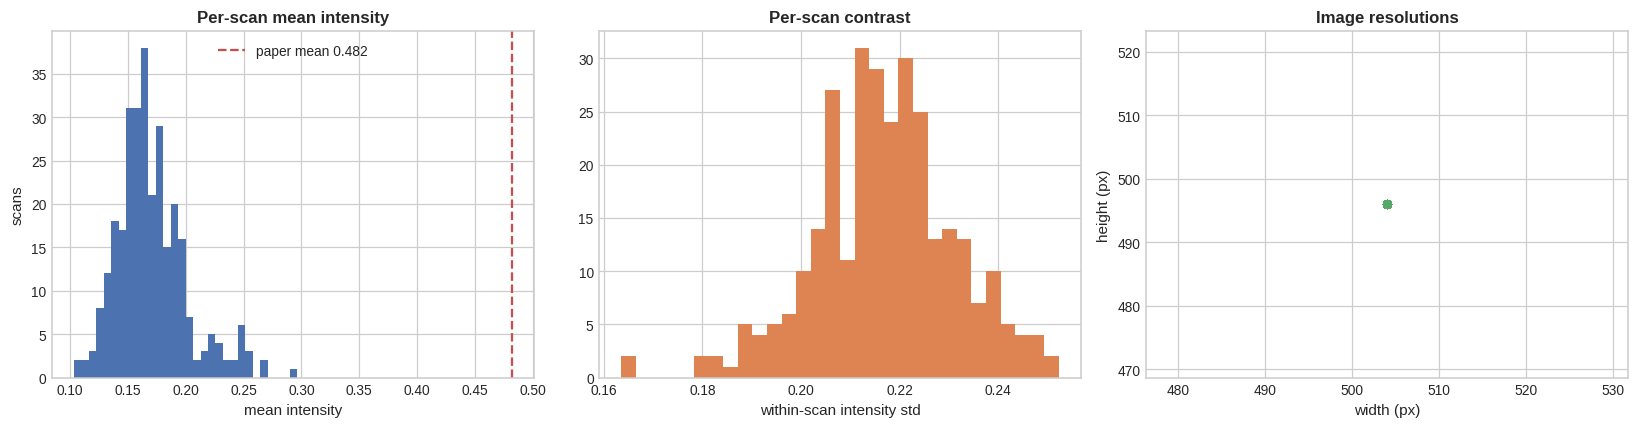

In [52]:
show(plotter.image_statistics(image_stats), "11_image_statistics")

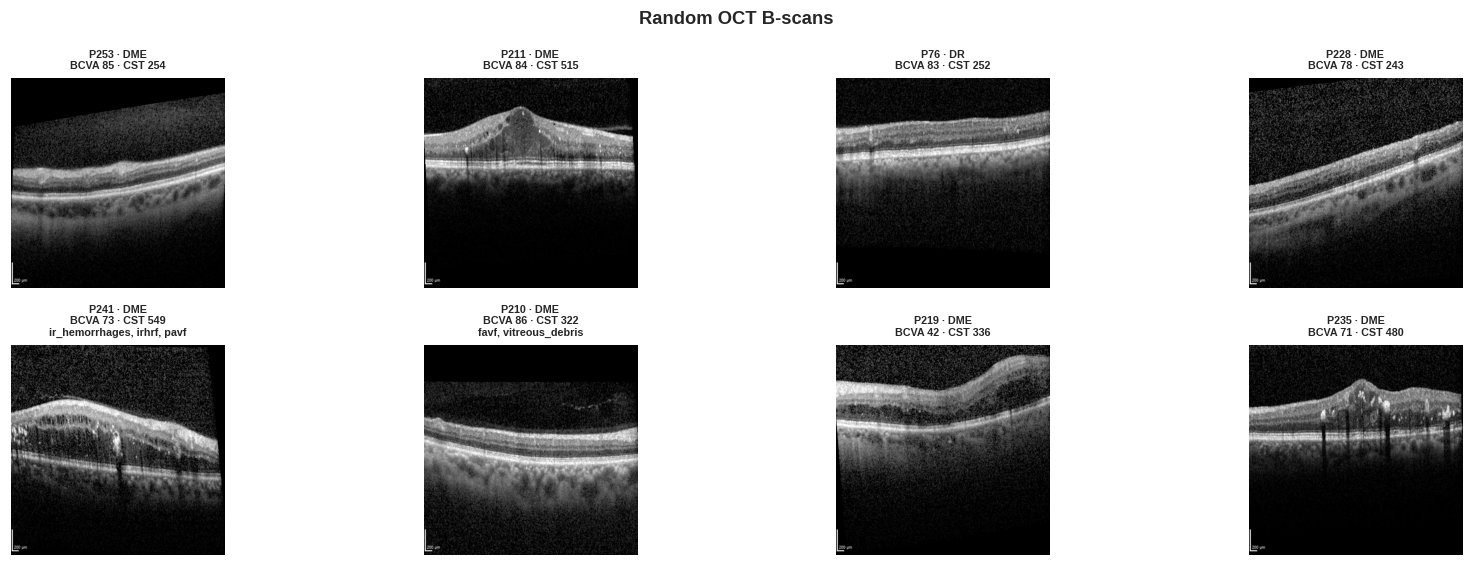

In [53]:
show(plotter.image_grid(eda.sample_images(reader, n=8, seed=7), n_cols=4,
                        title="Random OCT B-scans"), "11_sample_random")

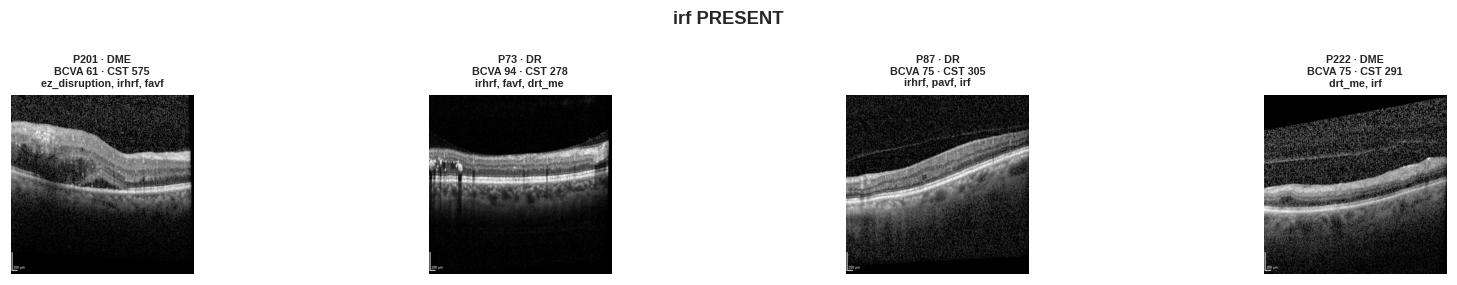

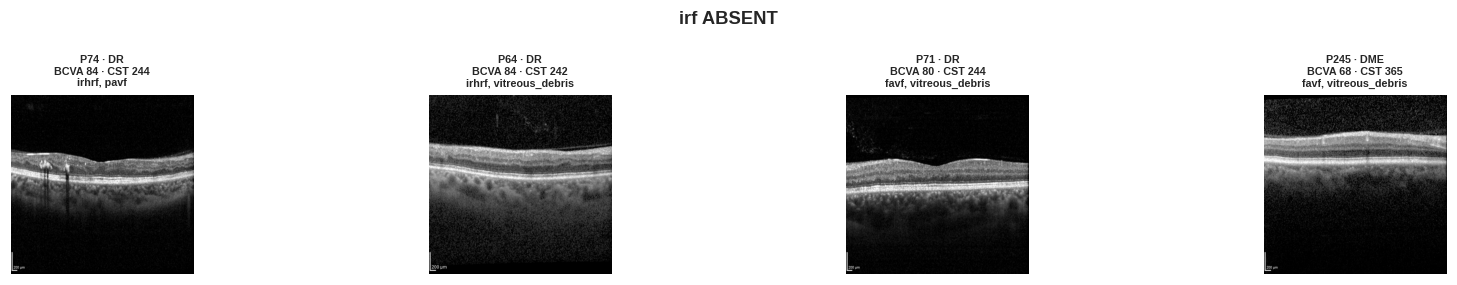

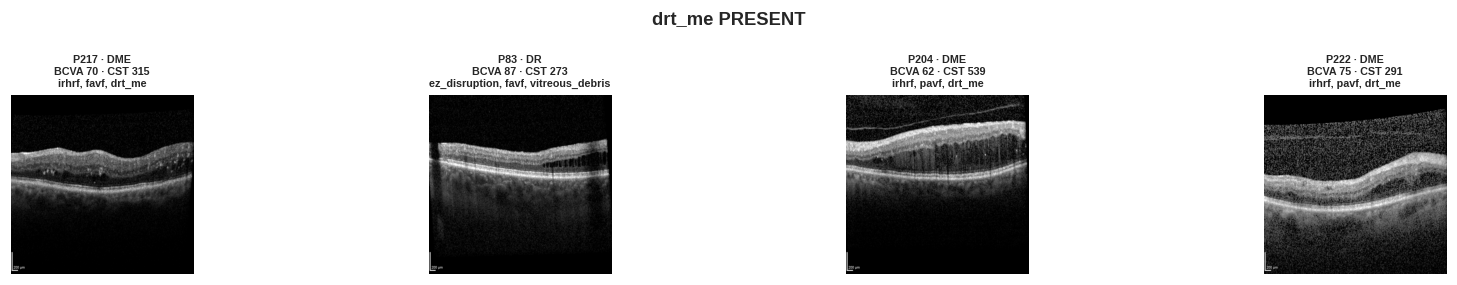

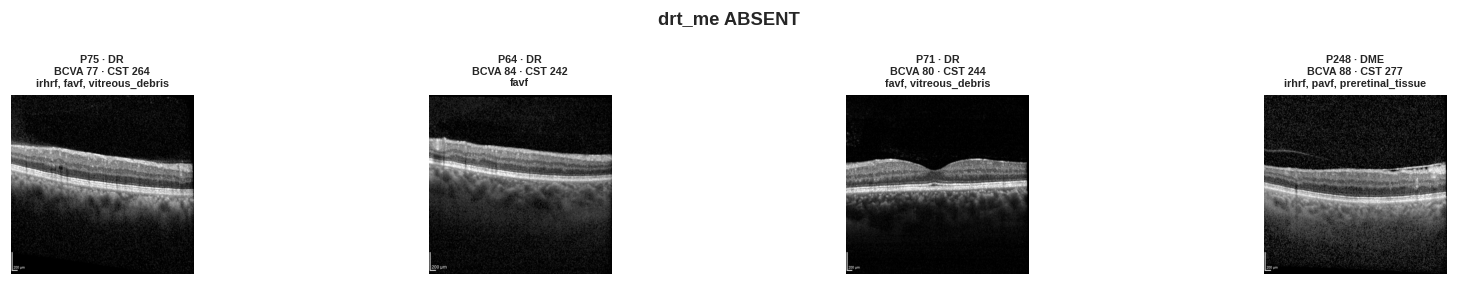

In [54]:
# Contrast scans with and without a biomarker - is it visible to the eye?
for label in ["irf", "drt_me"]:
    show(plotter.image_grid(eda.sample_images(reader, n=4, label=label, present=True, seed=3),
                            n_cols=4, title=f"{label} PRESENT"), f"11_sample_{label}_present")
    show(plotter.image_grid(eda.sample_images(reader, n=4, label=label, present=False, seed=3),
                            n_cols=4, title=f"{label} ABSENT"), f"11_sample_{label}_absent")

### Exporting an image cache (needed for Colab)

Training does not need all 30 GB — only the 9,396 labelled, deduplicated scans. Exporting them as
PNGs gives a folder small enough to upload to Drive and fast enough for random access.

Run once, locally, then upload `data/processed/images_labelled/`.

In [55]:
from olives_biomarkers.data.dataset import ImageCacheExporter

EXPORT_IMAGES = False   # set True to run the one-off export

if EXPORT_IMAGES:
    exporter = ImageCacheExporter(
        pipeline.data_root,
        pipeline.config.data.config_name,
        output_dir=REPO_ROOT / "data" / "processed" / "images_labelled",
        split="train",
    )
    cached = exporter.export(eda.labelled)
    print(f"cache size: {exporter.cache_size_gb():.2f} GB")
    cached[["row_uid", "patient_id", "cache_path"]].head()
else:
    print("EXPORT_IMAGES is False - set it to True to build the Colab-friendly image cache.")

EXPORT_IMAGES is False - set it to True to build the Colab-friendly image cache.


---
## 12. Split design

Everything above converges on one constraint: **partition patients, never scans**.

In [56]:
eda.leakage_risk_summary()

,grouping,n_groups,mean_scans_per_group,effective_sample_size_if_split_here
0,patient,87,810.8000,87
1,patient x eye,97,727.2000,97
2,patient x eye x visit,1440,49.0000,1440
3,individual scan,70541,1.0000,70541


Read the last column as the honest sample size. Splitting at the scan level would suggest tens of
thousands of independent observations; the truth is **87**. A random image-level split would place
49 near-identical slices of one volume on both sides and report an accuracy that means nothing.

In [57]:
assignment = pipeline.make_holdout_split(manifest, write=True)
pd.DataFrame(
    {
        "partition": list(assignment.partitions),
        "n_patients": [len(v) for v in assignment.partitions.values()],
    }
)

09:08:30 | INFO    | olives.splits | holdout split 'holdout': train=52 val=13 test=13 calibration=9 patients
09:08:30 | INFO    | olives.splits | split manifests written to /content/ClinBioGate/data/manifests/splits


,partition,n_patients
0,train,52
1,val,13
2,test,13
3,calibration,9


In [58]:
from olives_biomarkers.data.splits import SplitManifestWriter

modelling = manifest.modelling_frame(policy="keep_first", labelled_only=True)
writer = SplitManifestWriter(pipeline.split_dir)
writer.prevalence_by_partition(modelling, assignment, manifest.label_columns)

,partition,n_patients,n_rows,n_labelled_rows,atrophy_thinning,ez_disruption,dril,ir_hemorrhages,irhrf,pavf,favf,preretinal_tissue,vitreous_debris,vmt,drt_me,irf,srf,rpe_disruption,ped_serous,shrm
0,calibration,9,882,882,0.0000,0.0283,0.0215,0.0658,0.5612,0.2993,0.6497,0.1961,0.2336,0.0000,0.1780,0.3027,0.0181,0.0000,0.0000,0.0011
1,test,13,1372,1372,0.0226,0.0437,0.0000,0.0386,0.7092,0.2026,0.6363,0.1057,0.3499,0.0000,0.3746,0.5182,0.0372,0.0007,0.0000,0.0146
2,train,52,5672,5672,0.0215,0.0733,0.0023,0.0406,0.6784,0.3699,0.4898,0.0785,0.2683,0.0018,0.3447,0.4616,0.0240,0.0016,0.0018,0.0079
3,val,13,1470,1470,0.0088,0.0701,0.0000,0.0218,0.6952,0.2340,0.6748,0.0299,0.4272,0.0000,0.2565,0.3340,0.0204,0.0000,0.0000,0.0068


Compare prevalence across partitions. Common labels should track closely; rare ones will swing
wildly or read 0.0 in some partitions — a limitation to report explicitly, not to fix by
reshuffling until it looks good.

The `calibration` partition is carved out of *train* and is patient-disjoint from everything else,
so temperature scaling never sees data that fitted the model weights.

In [59]:
folds = pipeline.make_folds(manifest, write=True)
pd.DataFrame(
    [
        {
            "fold": f.name,
            "train": len(f.train),
            "val": len(f.val),
            "calibration": len(f.calibration),
            "test": len(f.test),
        }
        for f in folds
    ]
)

09:08:30 | INFO    | olives.splits | built 5 patient-grouped folds
09:08:30 | INFO    | olives.splits | split manifests written to /content/ClinBioGate/data/manifests/splits
09:08:30 | INFO    | olives.splits | split manifests written to /content/ClinBioGate/data/manifests/splits
09:08:30 | INFO    | olives.splits | split manifests written to /content/ClinBioGate/data/manifests/splits
09:08:30 | INFO    | olives.splits | split manifests written to /content/ClinBioGate/data/manifests/splits
09:08:30 | INFO    | olives.splits | split manifests written to /content/ClinBioGate/data/manifests/splits


,fold,train,val,calibration,test
0,fold_0,49,10,10,18
1,fold_1,49,10,10,18
2,fold_2,50,10,10,17
3,fold_3,50,10,10,17
4,fold_4,50,10,10,17


In [60]:
# Verify disjointness rather than trusting it.
from olives_biomarkers.data.splits import SplitValidator

validator = SplitValidator()
for fold in [assignment, *folds]:
    validator.validate(modelling, fold)
print(f"all {1 + len(folds)} splits verified: patients disjoint, duplicate groups contained")

all 6 splits verified: patients disjoint, duplicate groups contained


---
## 13. Findings

In [61]:
for i, finding in enumerate(eda.key_findings(), 1):
    print(f"{i}. {finding}\n")

1. Modelling set: 9,396 labelled scans from only 87 patients - the effective sample size is the patient count, not the scan count.

2. Each patient contributes ~811 labelled scans, so a random image-level split would put near-identical scans on both sides.

3. 21.01% of rows are byte-identical duplicates (8,281 groups); no groups cross a patient.

4. 5 of 16 biomarkers occur in under 1% of scans (shrm, dril, vmt, rpe_disruption, ped_serous) - per-label metrics for these will be unstable.

5. 4 labels are expected to yield too few test positives to evaluate at a 15% patient holdout; the 6-label MVP avoids all of them.

6. Scans carry 2.851 biomarkers on average across 292 distinct label vectors - genuinely multilabel, so per-label thresholds are needed rather than one global threshold.

7. CST separates 'srf' most strongly (Cohen's d = 1.647), which is where clinical fusion is most likely to help.



### What this means for the experimental design

**Settled by the data**

1. **Patient-grouped splitting is mandatory.** 87 patients, ~108 labelled scans each. The effective
   sample size is the patient count; every confidence interval must be a patient-level bootstrap.
2. **Deduplicate before anything else.** ~21% of rows are byte-identical repeats. They inflate
   every count and would corrupt any scan-level split.
3. **`has_biomarkers` is the filter for modelling rows** — not `scan_number`, which is present on
   only 22% of rows.
4. **Per-label thresholds, not 0.5.** Prevalence ranges from 67% to 0.06%.
5. **Report the 6-label MVP as the primary result**, with the 16-label model secondary and the rare
   labels reported as undefined where the test fold holds no positives.
6. **Do not use the paper's normalisation constants.** They do not match the pixel statistics here.

**Open questions the modelling has to answer**

7. Does CST's association with fluid biomarkers survive as a *conditional* effect once the image is
   in the model? Section 10 shows only a marginal association.
8. Can clinical features help at all at slice level, given one CST value covers all 49 slices of a
   volume while the labels vary between them? This bounds the plausible effect size for Models C
   and D — and makes a well-controlled negative result a legitimate outcome.

**Blocked**

9. Fundus and 3D-volume extensions: not possible with this mirror. They need the Zenodo release.
10. Visit-level results: visit indices are inferred and not authoritative.

### Next step

```bash
python scripts/audit_data.py --config configs/data.yaml     # reproduce sections 3-4
python scripts/build_manifest.py --config configs/data.yaml
python scripts/make_splits.py --config configs/data.yaml
```

Then Phase 2 — the clinical-only, OCT-only and concatenation baselines — using the fold manifests
written in section 12.